# Discrete Fourier Series (DFS) — Manual Implementation (No FFT)

**Course:** Signals / DSP  
**Homework:** DFS by correlation / inner products (`np.sum` / `np.dot`)  
**Students:** \
Chirino Sánchez Luis Fernando\
Dominguez Calihua Fernando\
Garay Hernández Jorge Efrén

**Date:** October 6th, 2026

---

## Objective

Implement the **Discrete Fourier Series (DFS)** for **periodic discrete-time** signals.

You must:

1. Construct **three** periodic discrete signals (one period only).
2. Compute DFS coefficients **manually** using the definition (correlation / inner product).
3. Reconstruct each signal from its coefficients.
4. Compare original vs reconstructed signals.
5. Report reconstruction error.

---

## Restrictions (IMPORTANT)

 Allowed:
- `numpy`, `matplotlib`
- `np.sum`, `np.dot`
- `np.exp`, complex numbers, loops (if you want)

 Not allowed:
- `np.fft.fft`, `np.fft.ifft`, or any FFT/DFT helper
- Any library function that directly returns Fourier coefficients


## DFS Definitions (use these)

We work with one period of a discrete-time periodic signal:
- Period: $$N$$
- Samples: $$n = 0,1,\dots,N-1$$
- Signal values: $$x[n]$$

### Complex exponential basis
$$
\phi_k[n] = e^{j\frac{2\pi}{N}kn},\quad k=0,1,\dots,N-1
$$

### Analysis (coefficients)
$$
X[k] = \frac{1}{N}\sum_{n=0}^{N-1} x[n]\;e^{-j\frac{2\pi}{N}kn}
$$

### Synthesis (reconstruction)
$$
\hat{x}[n] = \sum_{k=0}^{N-1} X[k]\;e^{j\frac{2\pi}{N}kn}
$$

### Reconstruction error (RMSE)
$$
\mathrm{RMSE} = \sqrt{\frac{1}{N}\sum_{n=0}^{N-1}\left|x[n]-\hat{x}[n]\right|^2}
$$

**Implementation requirement:** compute the sums using `np.sum` or `np.dot`.


In [ ]:
# === Imports ===
import numpy as np
import matplotlib.pyplot as plt

# Make plots a bit larger for readability (optional)
plt.rcParams["figure.figsize"] = (10, 4)

# For reproducibility (only matters if you add noise later)
np.random.seed(0)


## Deliverables (what you must submit)

For each of the three signals (A, B, C), include:

1) A plot of the signal over one period: $$x[n]$$, $$n=0..N-1$$  
2) A stem/bar plot of the magnitude spectrum: $$|X[k]|$$  
3) A plot of the phase spectrum: $$angle X[k]$$  
4) A plot comparing $$x[n]$$ and $$\hat{x}[n]$$ over one period  
5) RMSE value and 2–4 sentences of interpretation

---

## Signals to analyze

You must implement all DFS for **three different periods**:
N1 = 16
N2 = 32
N3 = 64

### Signal A — Square wave
One period definition:
- $$x_A[n] = 1$$ for $$0 \le n < N_1/2$$
- $$x_A[n] = -1$$ for $$N_1/2 \le n < N_1$$

### Signal B — Triangle wave
Build a discrete triangle over one period, peak amplitude 1 (or rescale to $$[-1,1]$$).

#Signal C — Sum of sinusoids
$$
x_C[n] =
0.8\cos\left(2\pi\frac{1}{N}n\right)
+ 0.4\sin\left(2\pi\frac{2}{N}n + 0.3\right)
+ 0.2\cos\left(2\pi\frac{3}{N}n - 0.8\right)
$$

In [ ]:
# === TODO 1: DFS (Analysis) ===
def dfs(x):
    N = len(x)
    n = np.arange(N)
    X = np.zeros(N, dtype=complex)
    for k in range(N):
        X[k] = (1.0 / N) * np.sum(x * np.exp(-1j * 2 * np.pi * k * n / N))
    return X

# === TODO 2: Inverse DFS (Synthesis) ===
def idfs(X):
    N = len(X)
    k = np.arange(N)
    x_hat = np.zeros(N, dtype=complex)
    for n in range(N):
        x_hat[n] = np.sum(X * np.exp(1j * 2 * np.pi * k * n / N))
    return x_hat


def rmse(x, x_hat):
    """Root-mean-square error over one period."""
    x = np.asarray(x)
    x_hat = np.asarray(x_hat)
    N = len(x)
    return np.sqrt((1.0 / N) * np.sum(np.abs(x - x_hat) ** 2))


In [ ]:
#Signal A
N1 = 32
n1 = np.arange(N1)
xA = np.where(n1 < N1 / 2, 1, -1)

#Signal B
N2 = 48
n2 = np.arange(N2)
xB = np.concatenate([
    np.linspace(-1, 1, N2 // 2, endpoint=False),
    np.linspace(1, -1, N2 // 2, endpoint=False)
])

# Signal C
N3 = 64
n3 = np.arange(N3)
xC = (0.8 * np.cos(2 * np.pi * 1 / N3 * n3) +
      0.4 * np.sin(2 * np.pi * 2 / N3 * n3 + 0.3) +
      0.2 * np.cos(2 * np.pi * 3 / N3 * n3 - 0.8))


## Helper plotting template (use or modify)

You may use `plt.stem` for discrete plots.  
When plotting phase, you can use `np.angle(X)` (optionally `np.unwrap`).

**Note:** Small imaginary parts in `x_hat` may appear due to numerical precision.  
If so, compare against `np.real(x_hat)` and report that you took the real part.


Signal A (square): N=32, RMSE=3.941218e-15


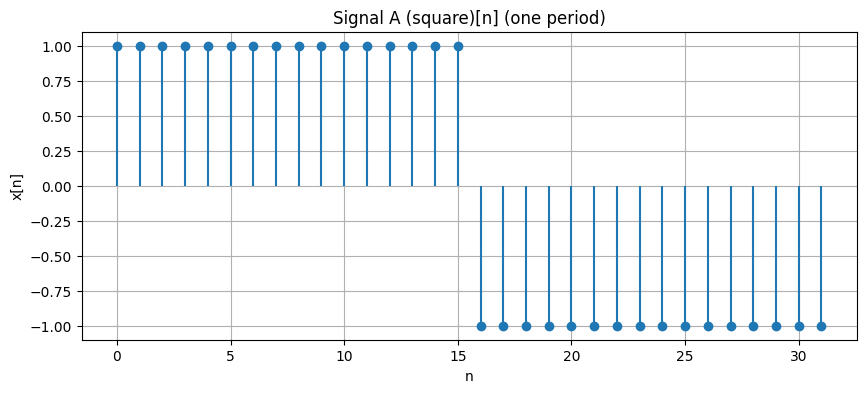

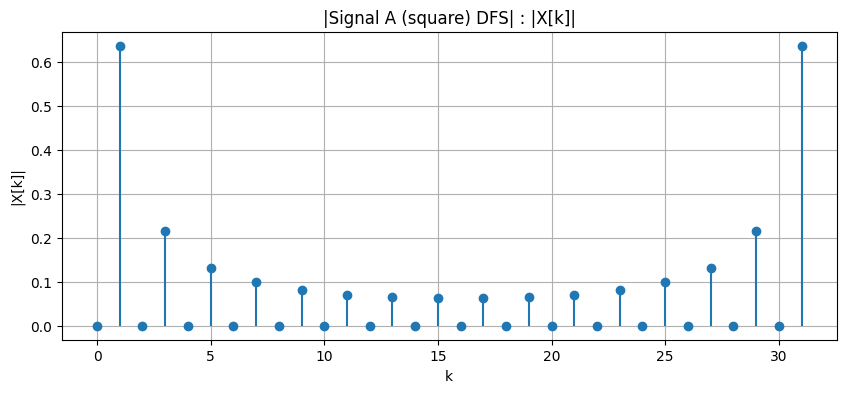

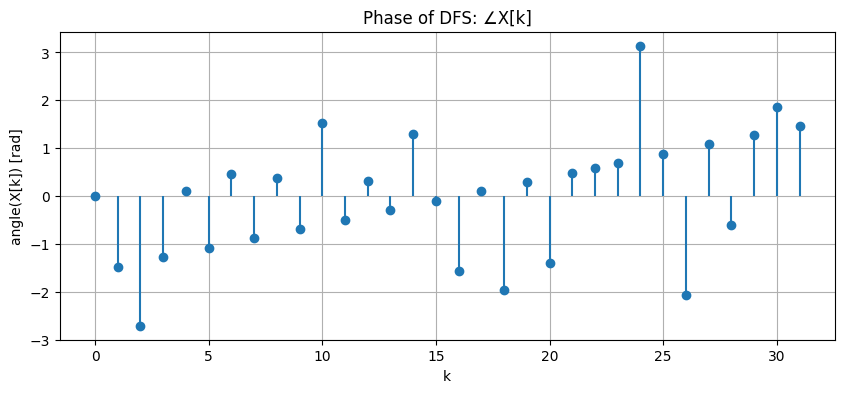

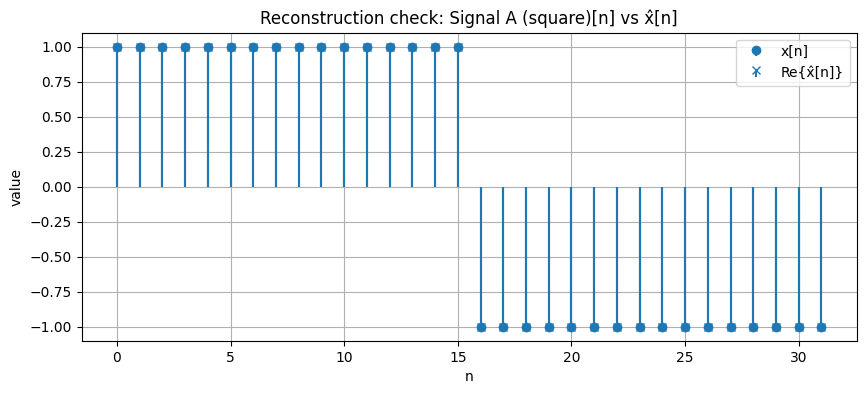

Signal B (triangle): N=48, RMSE=6.309443e-15


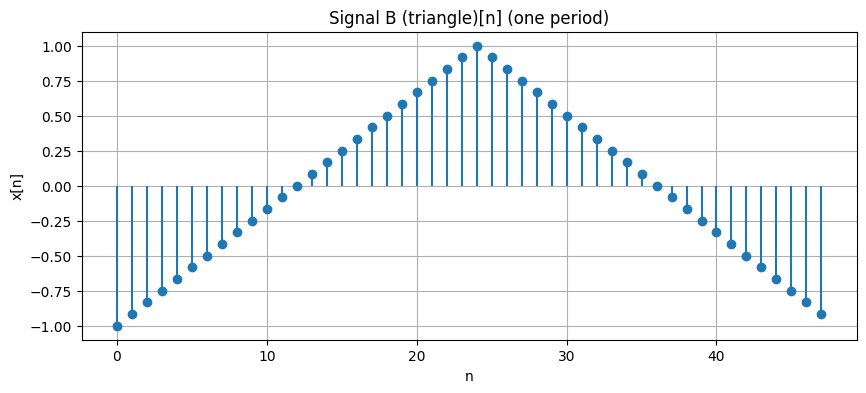

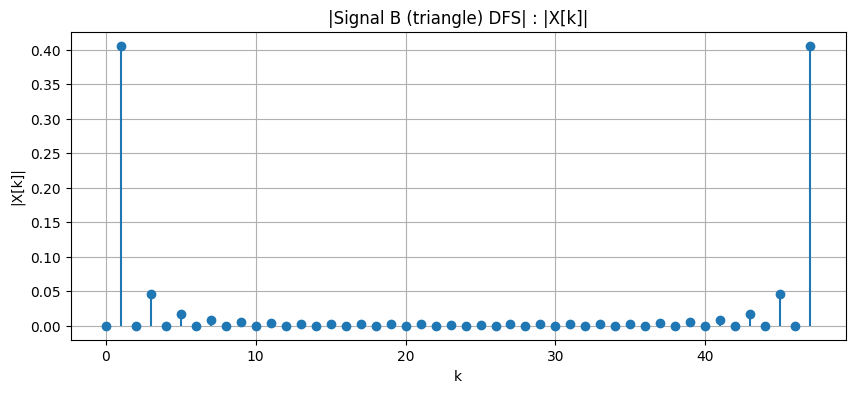

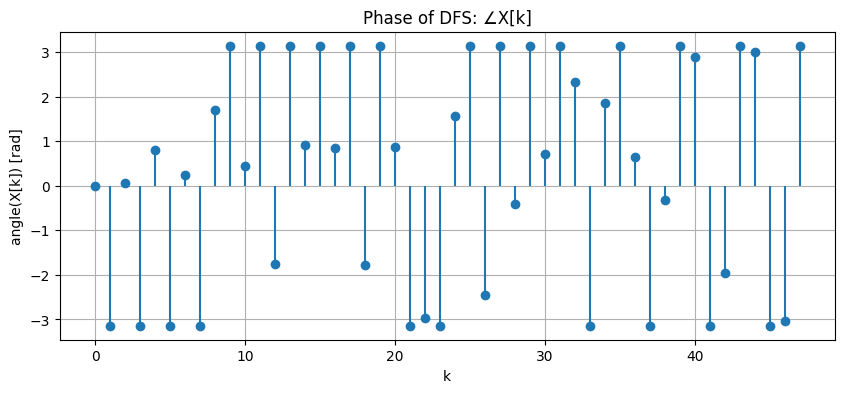

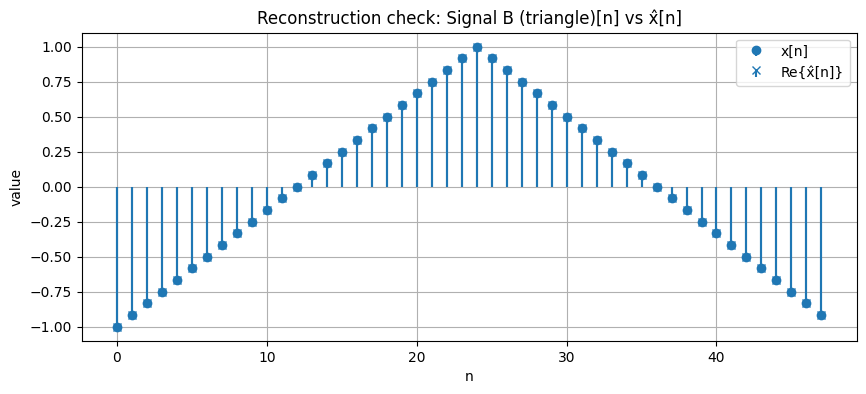

Signal C (sum of sinusoids): N=64, RMSE=7.342772e-15


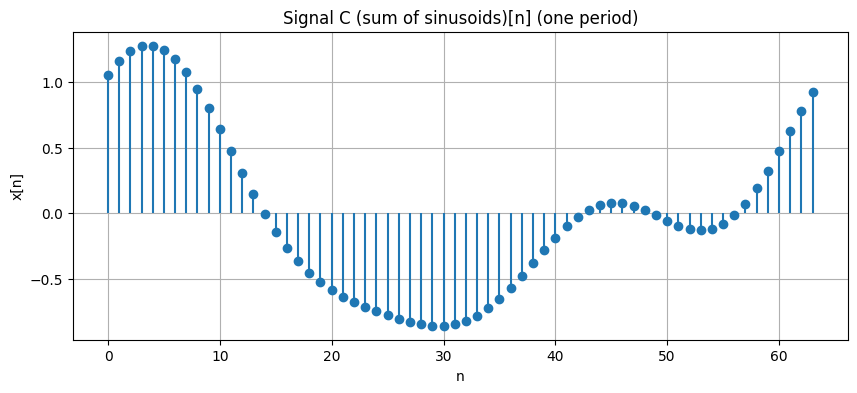

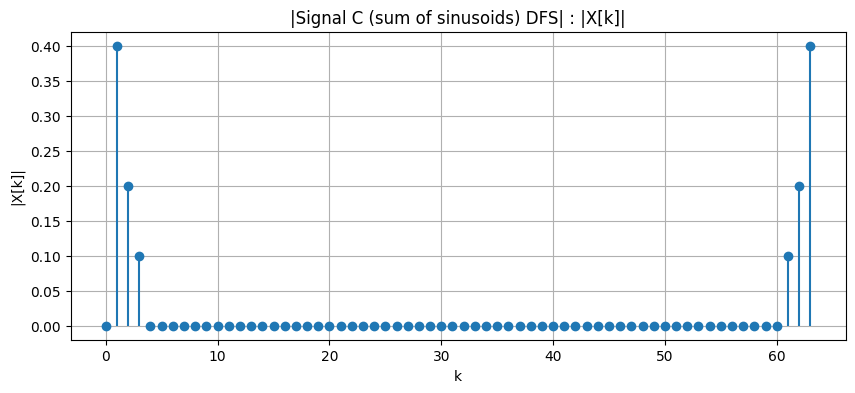

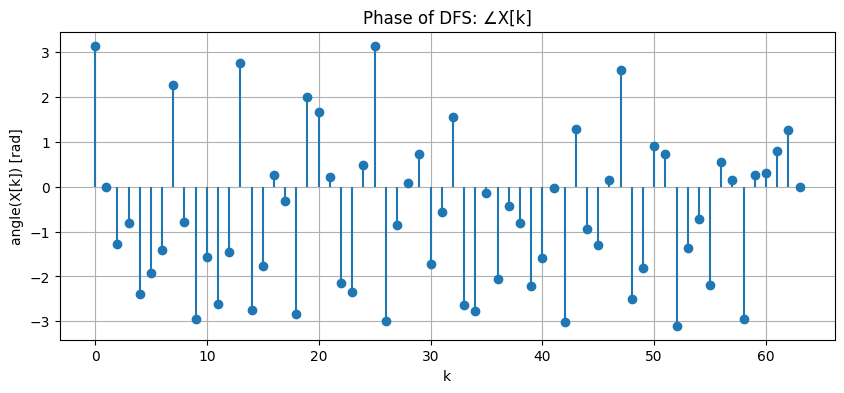

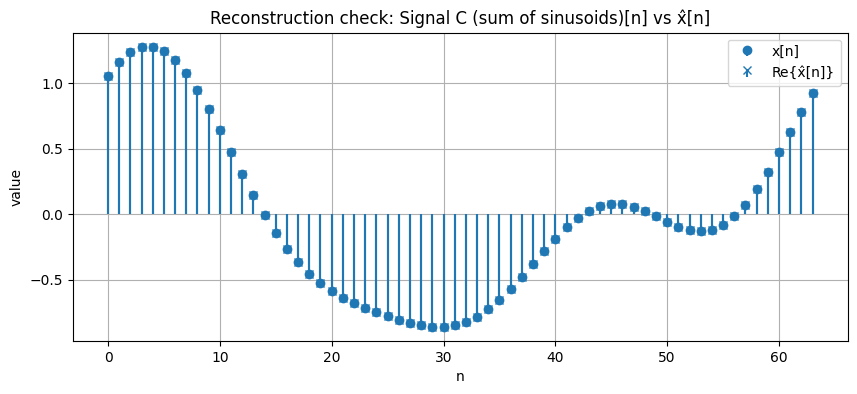

In [ ]:
def analyze_signal(x, name="x"):
    """Compute DFS, reconstruct, plot, and print RMSE for one period."""
    x = np.asarray(x)
    N = len(x)
    n = np.arange(N)

    # --- DFS / IDFS ---
    X = dfs(x)
    x_hat = idfs(X)

    # --- Error ---
    e = rmse(x, x_hat)
    print(f"{name}: N={N}, RMSE={e:.6e}")

    # --- Plots: time domain ---
    plt.figure()
    plt.stem(n, np.real(x), basefmt=" ")
    plt.title(f"{name}[n] (one period)")
    plt.xlabel("n"); plt.ylabel("x[n]")
    plt.grid(True)
    plt.show()

    # --- Plots: magnitude spectrum ---
    k = np.arange(N)
    plt.figure()
    plt.stem(k, np.abs(X), basefmt=" ")
    plt.title(f"|{name} DFS| : |X[k]|")
    plt.xlabel("k"); plt.ylabel("|X[k]|")
    plt.grid(True)
    plt.show()

    # --- Plots: phase spectrum ---
    plt.figure()
    plt.stem(k, np.angle(X), basefmt=" ")
    plt.title(f"Phase of DFS: ∠X[k]")
    plt.xlabel("k"); plt.ylabel("angle(X[k]) [rad]")
    plt.grid(True)
    plt.show()

    # --- Plots: reconstruction ---
    plt.figure()
    plt.stem(n, np.real(x), basefmt=" ", markerfmt="o", label="x[n]")
    plt.stem(n, np.real(x_hat), basefmt=" ", markerfmt="x", label="Re{x̂[n]}")

    plt.title(f"Reconstruction check: {name}[n] vs x̂[n]")
    plt.xlabel("n"); plt.ylabel("value")
    plt.grid(True)
    plt.legend()
    plt.show()

    return X, x_hat

XA, xA_hat = analyze_signal(xA, name="Signal A (square)")
XB, xB_hat = analyze_signal(xB, name="Signal B (triangle)")
XC, xC_hat = analyze_signal(xC, name="Signal C (sum of sinusoids)")


## Short reflection (write your answers here)

For each signal:

- How many coefficients (roughly) are “dominant” in magnitude?
- Does the phase look structured or noisy? Why?
- If you keep only the largest M coefficients (optional extension), what happens in reconstruction?

*(Write 2–4 sentences per signal.)*

**Para la señal A:**\
Se observa solo un coeficiente dominante en K=1, los siguientes coeficientes son mucho menores y van decreciendo lentamente. La fase se observa estructurada gracias a la simetria en la señal del tiempo, y si solo se conservarán los M coeficeintes mas grandes, la señal reconstruida presentará oscilaciones u ondulaciones justo en los bordes donde la onda cuadrada salta de 1 a -1.

**Para la señal B:**\
Muy pocos coeficientes son dominantes en magnitud, ya que los armónicos decaen muy rápido. La fase mantiene un patrón altamente estructurado y predecible debido a que la señal es continua y simétrica. Al usar solo los M coeficientes principales, la reconstrucción es casi idéntica a la original, perdiendo únicamente un poco de agudeza en los picos del triángulo, los cuales se vuelven ligeramente redondeados.

**Para la señal C:**\
Hay exactamente 6 coeficientes dominantes en el espectro de magnitud, correspondientes a los pares de frecuencias positivas y negativas de las tres funciones trigonométricas. La fase se ve estructurada en esas 6 frecuencias específicas, pero parece completamente ruidosa o aleatoria en el resto del espectro debido al ruido de máquina intentando calcular el ángulo de magnitudes cercanas a 0. Si se conservan solo los M componentes principales y M es al menos 6, la reconstrucción será muy idéntica; si es menor, la señal perderá una o más de sus ondas originales.